# Compression as an Agent Action — Final Report

**Two experiments, one conclusion.** Zero-shot Qwen3-VL-8B with a compression tool and a crop
tool, evaluated on VideoMME-long (882 questions) and LVBench (183 paired questions with
ground-truth evidence spans).

| | Experiment 1 | Experiment 2 |
|---|---|---|
| **benchmark** | VideoMME-long, n=882 paired | LVBench, n=183 paired |
| **question** | do compression + crop tools help an autonomous agent? | if localization were *solved*, would the tools pay off? |
| **method** | paired A/B, model chooses all spans | 4 arms; the harness supplies GT spans to two of them |
| **answer** | **no** — −1.0 pp, p=0.50 | **yes for location, no for compression** — +23.0 pp, p=3.1e-8 |

Read together they separate two things that every earlier null had conflated:

> **Localization is worth ~+23 pp and the agent captures none of it. Uniform compression is
> worth ~0 and cannot be made to pay by spending more tokens on it.**

Every number below is recomputed from the run artifacts at execution time — nothing is
transcribed. Sources: `outputs/fast_agent/runs/*/results.jsonl`,
`outputs/fast_agent/{official_flashvid,lossless_singleshot_n30*}/`,
`outputs/fast_agent/analysis/`.

In [1]:
import json, numpy as np, matplotlib
matplotlib.use("Agg"); import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

A  = "/local1/cfyang/hanklin/outputs/fast_agent/analysis"
N  = json.load(open(f"{A}/final_report_numbers.json"))
FT = json.load(open(f"{A}/final_report_features.json"))
E1, E2, Q = N["exp1"], N["exp2"], N["qid128"]
pct = lambda x: f"{100*x:.1f}%"
pp  = lambda x: f"{100*x:+.1f}pp"
print("artifacts loaded — exp1 n=%d paired, exp2 n=%d paired" % (E1["n_paired"], E2["n_paired"]))

artifacts loaded — exp1 n=882 paired, exp2 n=183 paired


## 0. What was built

A self-contained harness (`fast_agent/`) driving **zero-shot Qwen3-VL-8B-Instruct** through a
tool loop. Two tools, matched token budgets:

| tool | what it returns | budget |
|---|---|---|
| `crop_video(start, end)` | ≤128 frames @1 fps, **full detail**, image modality | ~6.1k tokens |
| `compress_video(start, end)` | up to 2,128 frames, **FlashVID-compressed** inside the ViT | ~6.1k tokens (retention 0.1, calibrated) |

The compression is real: FlashVID (DySeg + ADTS + TSTM) runs on the model's **own** ViT
output, and the surviving tokens enter the LM through the projection with M-RoPE computed on
the full grid — no second model, no pixel round-trip. Both tools cost the same, so
`compress_video` buys **temporal coverage at the price of per-frame detail**. That trade is
the object of study.

Every arm shares: the same 64-frame uniform skim, the same question text, greedy decode, the
same answer parser, the same bounded finalizer, and the same seeded question set.

---

# Experiment 1 — VideoMME-long: the autonomous agent

**Design.** 882 questions, paired. `baseline` = 64-frame skim, no tools. `compress` = the same
skim plus both tools, ≤5 rounds, the model choosing every span itself.

In [2]:
d = E1["delta"] = E1["compress"] - E1["baseline"]
print(f"n paired                 : {E1['n_paired']}")
print(f"baseline (skim, no tools): {pct(E1['baseline'])}")
print(f"+ crop + compress tools  : {pct(E1['compress'])}    delta {pp(d)}")
print(f"McNemar exact p          : {E1['p']:.2f}     bootstrap 95% CI [{pp(E1['ci'][0])}, {pp(E1['ci'][1])}]")
print(f"\ntool adoption            : {pct(E1['tool_adoption'])} of questions made >=1 call")
print(f"calls                    : {E1['calls']}")
print(f"\nflips: {E1['fixed']} wrong->right, {E1['broke']} right->wrong  "
      f"({E1['fixed']+E1['broke']} of {E1['n_paired']} answers changed = "
      f"{pct((E1['fixed']+E1['broke'])/E1['n_paired'])})")

n paired                 : 882
baseline (skim, no tools): 53.2%
+ crop + compress tools  : 52.2%    delta -1.0pp
McNemar exact p          : 0.50     bootstrap 95% CI [-3.7pp, +1.7pp]

tool adoption            : 99.9% of questions made >=1 call
calls                    : {'compress_video': 347, 'crop_video': 1746}

flips: 67 wrong->right, 76 right->wrong  (143 of 882 answers changed = 16.2%)


### 1.1 The null is *churn*, not inertness

The tools are used on **99.9%** of questions — this is not a case of the model ignoring them.
**16% of all answers change**, and they change symmetrically: 67 repaired, 76 broken. The
agent is doing a great deal of work for a net loss of one percentage point that a coin flip
would produce half the time.

This matters because "no effect" and "large offsetting effects" have different fixes. There is
no missing capability to *add* here — the capability is present and misapplied. What is
missing is a rule for **when** to apply it.

### 1.2 Per-task: the coverage/detail split is visible but doesn't sum to a gain

task                         n   baseline   +tools     delta
OCR Problems                14      42.9%    57.1%   +14.3pp
Spatial Reasoning           11      63.6%    72.7%    +9.1pp
Object Reasoning           238      49.2%    51.7%    +2.5pp
Information Synopsis       160      73.1%    73.8%    +0.6pp
Action Recognition          62      43.5%    41.9%    -1.6pp
Object Recognition          52      46.2%    44.2%    -1.9pp
Temporal Reasoning          90      43.3%    40.0%    -3.3pp
Action Reasoning           173      52.0%    47.4%    -4.6pp
Attribute Perception        25      68.0%    60.0%    -8.0pp
Counting Problem            48      41.7%    33.3%    -8.3pp


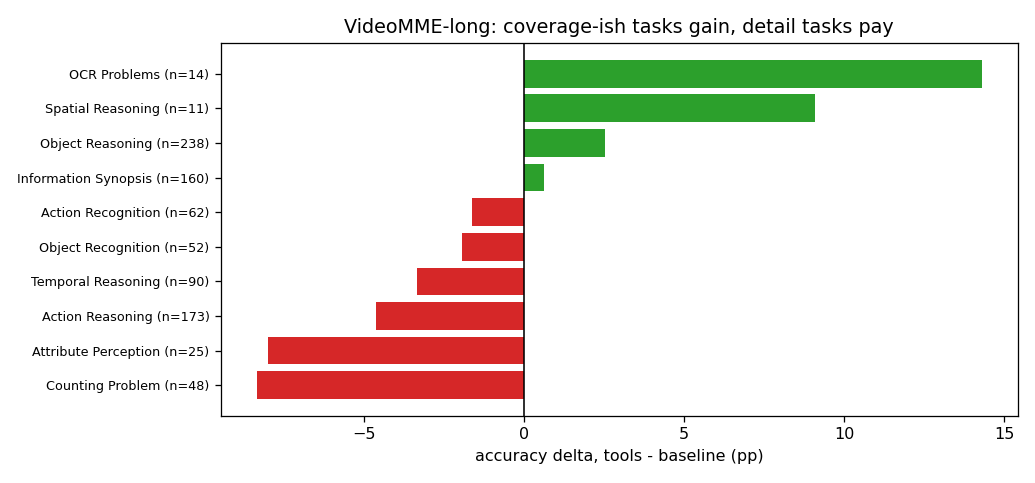

In [3]:
bt = E1["by_task"]
order = sorted(bt, key=lambda t: -bt[t]["delta"])
print(f"{'task':<24} {'n':>5} {'baseline':>10} {'+tools':>8} {'delta':>9}")
for t in order:
    v = bt[t]
    print(f"{t:<24} {v['n']:>5} {pct(v['base']):>10} {pct(v['comp']):>8} {pp(v['delta']):>9}")

fig, ax = plt.subplots(figsize=(9, 4.2))
y = np.arange(len(order))
vals = [bt[t]["delta"]*100 for t in order]
ax.barh(y, vals, color=["#2CA02C" if v > 0 else "#D62728" for v in vals])
ax.set_yticks(y); ax.set_yticklabels([f"{t} (n={bt[t]['n']})" for t in order], fontsize=8)
ax.axvline(0, color="k", lw=1); ax.invert_yaxis()
ax.set_xlabel("accuracy delta, tools - baseline (pp)")
ax.set_title("VideoMME-long: coverage-ish tasks gain, detail tasks pay")
plt.tight_layout(); plt.savefig("/tmp/e1_task.png", dpi=115); plt.close()
display(Image("/tmp/e1_task.png"))

The sign pattern is the routing hypothesis in miniature — OCR and Spatial Reasoning gain,
Counting and Attribute Perception lose. But the cell counts are small (n=14, n=11 on the
winners; n=48, n=25 on the losers) and the **sum is negative**. A tool that helps where
coverage matters and hurts where detail matters is exactly a tool that needs a router.
Zero-shot, there isn't one.

### 1.3 Is the null our implementation's fault?

Necessary check before concluding anything about compression. We ran the **official FlashVID
code path** — their `flashvid()` wrapper (vision **and** inner-LLM FastV pruning at layer 28),
their published Qwen3-VL hyperparameters, stock `process_vision_info`, and stock
`model.generate` — on the same 30 VideoMME-long questions.

In [4]:
off = E1["official"]
print("OFFICIAL FlashVID, stock model.generate, n=30 VideoMME-long")
print(f"{'config':<12} {'acc':>7} {'input tokens':>14}   note")
notes = {"base32": "no compression (reference)", "fv32_r10": "same 32 frames, retention 0.10",
         "fv32_r15": "same 32 frames, retention 0.15", "fv32_r20": "same 32 frames, retention 0.20",
         "fv32_r25": "same 32 frames, retention 0.25",
         "fv320_r10": "10x frames @0.10 - their headline config"}
base = off["base32"]["acc"]
for k in ["base32", "fv32_r10", "fv32_r15", "fv32_r20", "fv32_r25", "fv320_r10"]:
    v = off[k]
    dl = "" if k == "base32" else f"  ({pp(v['acc']-base)})"
    print(f"{k:<12} {pct(v['acc']):>7} {v['tok']:>14,}   {notes[k]}{dl}")

OFFICIAL FlashVID, stock model.generate, n=30 VideoMME-long
config           acc   input tokens   note
base32         53.3%          2,013   no compression (reference)
fv32_r10       43.3%          2,013   same 32 frames, retention 0.10  (-10.0pp)
fv32_r15       50.0%          2,013   same 32 frames, retention 0.15  (-3.3pp)
fv32_r20       43.3%          2,013   same 32 frames, retention 0.20  (-10.0pp)
fv32_r25       50.0%          2,013   same 32 frames, retention 0.25  (-3.3pp)
fv320_r10      50.0%         11,973   10x frames @0.10 - their headline config  (-3.3pp)


**FlashVID never beats its own baseline on this slice — at any retention, including the
10×-frames configuration the paper leads with.** So the null is not our port.

Two details worth keeping. The `input_tokens` column shows `base32` and every `fv32_*` run at
an **identical 2,013 tokens** — official FlashVID prunes *inside* the LLM, so the input is
unchanged and the −10 pp at retention 0.10 is an inner-LLM effect, not a budget effect. And
`fv320_r10` costs **11,973** tokens, ~6× base32, so it is not the "same budget, 10× frames"
comparison it is usually read as.

This is a **regime** result, not a refutation of the method. FlashVID is a legitimate ICLR'26
paper with real gains on shorter benchmarks and weaker base models. On hour-long,
evidence-sparse video with a strong base model that already scores 53%, token-redundancy
compression has nothing to give — the bottleneck is not redundancy.

### 1.4 Then what *does* help? A single-shot ladder with no agent at all

Strip out the loop, the tools, and the decisions. Same 30 questions, one generation each, only
the visual input differs.

In [5]:
ss = E1["singleshot"]
print("SINGLE-SHOT, no agent loop, n=30 (same questions)")
print(f"{'view':<14} {'frames':>7} {'tokens':>8} {'acc':>8}")
for k in ["skim64", "unif_matched", "comp640", "full640"]:
    v = ss[k]
    print(f"{k:<14} {v['n_frames']:>7} {v['tok']:>8,} {pct(v['acc']):>8}")

u, c = ss["unif_matched"], ss["comp640"]
uo = sum(1 for q in u["preds"] if u["preds"][q] == u["gold"][q] and c["preds"][q] != c["gold"][q])
co = sum(1 for q in c["preds"] if c["preds"][q] == c["gold"][q] and u["preds"][q] != u["gold"][q])
both = sum(1 for q in u["preds"] if u["preds"][q] == u["gold"][q] and c["preds"][q] == c["gold"][q])
print(f"\nMATCHED BUDGET (~2.3k tokens): uniform {pct(u['acc'])} vs FlashVID {pct(c['acc'])}"
      f"  =  {pp(u['acc']-c['acc'])} for the dumb baseline")
print(f"  uniquely right: uniform {uo}, FlashVID {co}, both {both}")

SINGLE-SHOT, no agent loop, n=30 (same questions)
view            frames   tokens      acc
skim64              64    2,880    36.7%
unif_matched       104    2,340    46.7%
comp640            640    2,303    33.3%
full640            640   14,400    50.0%

MATCHED BUDGET (~2.3k tokens): uniform 46.7% vs FlashVID 33.3%  =  +13.3pp for the dumb baseline
  uniquely right: uniform 4, FlashVID 0, both 10


Three readings, in order of importance:

1. **At matched budget a uniform subsample beats FlashVID**, and FlashVID is uniquely right on
   essentially nothing. Spending a fixed budget on "salient" tokens is *worse* than spreading it
   evenly. Section 2.7 shows the mechanism directly.
2. **Frames help when you pay for them.** 64 frames @2.9k tokens → 36.7%; 640 frames @14.4k
   tokens → 50.0%. The model is not saturated at 32 frames — an earlier claim in this project
   that this run retracts. What fails is squeezing 10× the frames into 1× the tokens.
3. **~104 uniform frames at 2.3k tokens (46.7%) nearly matches 640 uncompressed frames at
   14.4k (50.0%).** Whatever these questions need is recoverable from ~100 evenly spread
   frames. FlashVID spends the same budget concentrating on few regions and starves coverage.

### 1.5 A caution about all zero-shot A/Bs on this model

Rerunning 192 questions with one instruction reworded ("call a tool only if needed evidence is
missing") dropped tool adoption from **99.9% to 11%**, and `compress_video` fired **once** in
192 questions. On that rerun, **45 of 53 flips involved zero tool calls** — the arms differed
only in prompt text.

So a meaningful fraction of the churn in §1.1 is prompt noise rather than tool effect. This is
itself evidence for the thesis: a zero-shot "policy" that a wording change can delete was never
a policy. But it also means paired zero-shot A/Bs are a blunt instrument, which is the direct
motivation for Experiment 2 — an arm whose behaviour the prompt cannot swing.

### 1.6 Experiment 1 verdict

- Compression + crop as zero-shot agent tools: **no gain** (−1.0 pp, p=0.50), with 16% of
  answers churning symmetrically.
- **Not an implementation artifact** — official FlashVID reproduces the null on its own code.
- **Not a token-budget artifact** — more frames *do* help when paid for; compression at matched
  budget loses to uniform sampling.
- The zero-shot tool policy is **prompt-fragile to the point of collapse**.

What this cannot tell us: whether the tools failed because the *evidence never arrived*, or
because the tools are useless once it does. VideoMME-long has no per-question evidence
timestamps, so the question is unanswerable here. That is why Experiment 2 exists.

---

# Experiment 2 — LVBench: what if localization were solved?

**Why LVBench.** It ships `time_reference` — a **ground-truth evidence span per question**.
That lets the harness *supply* the answer's location and measure what a perfect WHERE-policy
would be worth, decoupled from whether the model can find it.

**Four arms, fully paired, identical in every respect except who chooses the spans:**

| arm | tools shown | who picks the span | measures |
|---|---|---|---|
| `direct` | none | — | the model alone |
| `autonomous` | crop | the model | the zero-shot policy |
| `oracle_crop` | crop | **harness, at the GT span** | perception given perfect localization |
| `oracle_ctrl` | crop | **harness, same width, wrong place** | the control for "more pixels" |

`oracle_ctrl` is the arm that makes this an experiment rather than a demonstration. It hands
the model exactly as many extra full-detail frames as `oracle_crop` does, placed **away** from
the evidence. If extra pixels were what helped, both oracles would rise together.

In [6]:
acc, ct = E2["acc"], E2["contrasts"]
print(f"n paired = {E2['n_paired']}  ({E2['n_ctrl_impossible']} dropped: evidence spans the "
      f"whole video, so no control placement exists)\n")
for k in ["direct", "autonomous", "oracle_crop", "oracle_ctrl"]:
    print(f"  {k:<12} {pct(acc[k]):>7}")
print()
for k, lbl in [("autonomous-direct", "zero-shot tool use is worth"),
               ("oracle_ctrl-direct", "extra pixels in the WRONG place are worth"),
               ("oracle_crop-direct", "perfect localization is worth"),
               ("oracle_crop-oracle_ctrl", "**LOCATION, holding pixels constant**, is worth")]:
    v = ct[k]
    print(f"{lbl:<52} {pp(v['delta']):>8}   p={v['p']:.2g}   "
          f"CI [{pp(v['ci'][0])}, {pp(v['ci'][1])}]   (+{v['fixed']}/-{v['broke']})")

n paired = 183  (17 dropped: evidence spans the whole video, so no control placement exists)

  direct         31.7%
  autonomous     33.3%
  oracle_crop    57.4%
  oracle_ctrl    34.4%

zero-shot tool use is worth                            +1.6pp   p=0.77   CI [-5.5pp, +8.7pp]   (+25/-22)
extra pixels in the WRONG place are worth              +2.7pp   p=0.51   CI [-3.8pp, +9.3pp]   (+21/-16)
perfect localization is worth                         +25.7pp   p=1.3e-08   CI [+17.5pp, +33.9pp]   (+59/-12)
**LOCATION, holding pixels constant**, is worth       +23.0pp   p=3.1e-08   CI [+15.3pp, +30.6pp]   (+51/-9)


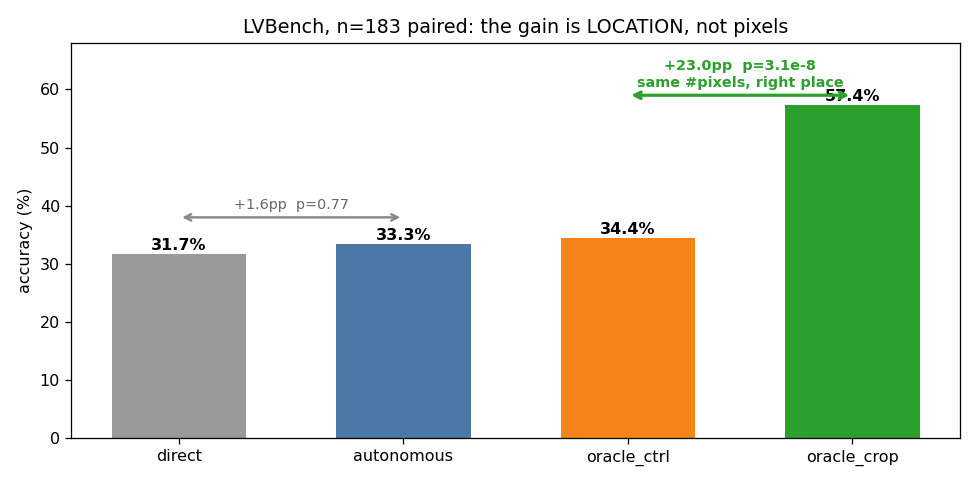

In [7]:
labels = ["direct", "autonomous", "oracle_ctrl", "oracle_crop"]
vals = [acc[k]*100 for k in labels]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.bar(labels, vals, color=["#999", "#4C78A8", "#F58518", "#2CA02C"], width=.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+.7, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 68)
ax.annotate("", xy=(3, 59), xytext=(2, 59),
            arrowprops=dict(arrowstyle="<->", color="#2CA02C", lw=2))
ax.text(2.5, 60.5, f"+23.0pp  p=3.1e-8\nsame #pixels, right place",
        ha="center", color="#2CA02C", fontweight="bold", fontsize=9)
ax.annotate("", xy=(1, 38), xytext=(0, 38),
            arrowprops=dict(arrowstyle="<->", color="#888", lw=1.5))
ax.text(.5, 39.5, "+1.6pp  p=0.77", ha="center", color="#666", fontsize=9)
ax.set_title("LVBench, n=183 paired: the gain is LOCATION, not pixels")
plt.tight_layout(); plt.savefig("/tmp/e2_arms.png", dpi=115); plt.close()
display(Image("/tmp/e2_arms.png"))

### 2.1 The load-bearing result

**`oracle_crop − oracle_ctrl = +23.0 pp, p = 3.1e-8, CI [+15.3, +30.6].**

Both arms receive one forced full-detail crop of identical width. The only difference is
*where*. The control lands statistically on top of `direct` (+2.7 pp, p=0.51) — so extra
full-detail frames in the wrong place are worth **nothing**, and the entire oracle gain is
attributable to **placement**.

Meanwhile the autonomous arm — the model choosing for itself — captures **+1.6 pp of that
+23 pp, p=0.77.** There is a large, real prize, and the zero-shot policy collects
approximately none of it.

This is the single most important number in the project, and it is **immune to the harness
caveat in §3.1**, because both arms share the same decode path and the same refusal regime.

### 2.2 Mechanism: the model is not blind, it is out of reach

If the autonomous arm were failing at *perception*, its accuracy would be low wherever it
looked. It isn't. What is low is whether it ever arrives.

In [8]:
cov, hm, sp = FT["coverage"], FT["hit_vs_miss"], FT["spans"]
print("DID THE AUTONOMOUS ARM EVER LOOK AT THE EVIDENCE?")
print(f"  mean GT coverage                : {cov['mean']:.2f}")
print(f"  questions with ZERO coverage    : {pct(cov['zero'])}")
print(f"  questions fully covering the GT : {pct(cov['full'])}")
print("\nSEARCH GEOMETRY")
print(f"  median video duration           : {sp['median_duration']:.0f}s")
print(f"  median crop calls per question  : {sp['median_calls']:.0f}")
print(f"  median crop width               : {sp['median_width']:.0f}s")
print(f"  median GT evidence width        : {sp['median_ev_width']:.0f}s")
print(f"  median FRACTION OF VIDEO SEEN   : {pct(sp['median_video_fraction_seen'])}")
print("\nAIM QUALITY (corr between crop centre and evidence centre)")
print(f"  on questions it covered         : r = {FT['aim']['r_on_hit']:.2f}")
print(f"  on questions it missed          : r = {FT['aim']['r_on_miss']:.2f}")
print("\nACCURACY ONCE IT ARRIVES (coverage = 1.0)")
print(f"  autonomous on covered (n={hm['n_hit']:>3})    : {pct(hm['crop_acc_on_hit'])}")
print(f"  oracle on the same questions    : {pct(hm['oracle_acc_on_hit'])}")

DID THE AUTONOMOUS ARM EVER LOOK AT THE EVIDENCE?
  mean GT coverage                : 0.18
  questions with ZERO coverage    : 78.7%
  questions fully covering the GT : 15.3%

SEARCH GEOMETRY
  median video duration           : 3620s
  median crop calls per question  : 1
  median crop width               : 54s
  median GT evidence width        : 14s
  median FRACTION OF VIDEO SEEN   : 1.6%

AIM QUALITY (corr between crop centre and evidence centre)
  on questions it covered         : r = 0.95
  on questions it missed          : r = 0.25

ACCURACY ONCE IT ARRIVES (coverage = 1.0)
  autonomous on covered (n= 28)    : 42.9%
  oracle on the same questions    : 50.0%


Read that block twice. The autonomous agent inspects a **median 1.6% of the video** — one
crop of ~54 s in a ~3,600 s video — and misses the evidence entirely on **79%** of questions.
But on the questions where it *does* land on the evidence, its aim is nearly perfect
(**r = 0.95** between where it looked and where the evidence was, vs r = 0.25 when it misses)
and it scores **42.9% there against the oracle's 50.0% on those same 28 questions** — most of
the way to the ceiling, on a cell small enough that the 7 pp gap is not resolvable.

**The model knows what it is looking for. It cannot cover enough ground to find it.** The
budget allows 5 calls, but the median question spends **1 call of 54 s** against a median
evidence width of 14 s in a 3,620 s video. Even spending all five at that width covers under
8% of the video. This is arithmetic, not a capability gap.

The cleanest confirmation is a natural experiment inside the benchmark. 26 of the 183 LVBench
questions **state their own timestamp** ("What happens from 17:16–17:40?"), which hands the
model the location in text:

                                          n   GT coverage   accuracy
question states its own timestamp        26          0.56      57.7%
question does not                       157          0.12      29.3%

difference: coverage +0.44, accuracy +28.4pp


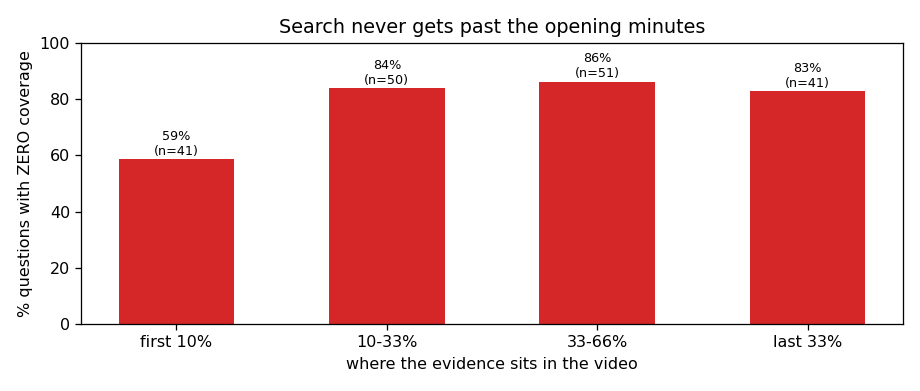

In [9]:
tv = FT["trivial"]
print(f"{'':<38}{'n':>5} {'GT coverage':>13} {'accuracy':>10}")
print(f"{'question states its own timestamp':<38}{tv['n_trivial']:>5} "
      f"{tv['cov_trivial']:>13.2f} {pct(tv['crop_acc_trivial']):>10}")
print(f"{'question does not':<38}{tv['n_nontrivial']:>5} "
      f"{tv['cov_nontrivial']:>13.2f} {pct(tv['crop_acc_nontrivial']):>10}")
print(f"\ndifference: coverage {tv['cov_trivial']-tv['cov_nontrivial']:+.2f}, "
      f"accuracy {pp(tv['crop_acc_trivial']-tv['crop_acc_nontrivial'])}")

pos = FT["zero_cov_by_position"]
fig, ax = plt.subplots(figsize=(8, 3.4))
ks = list(pos); v = [pos[k]["zero_cov"]*100 for k in ks]
ax.bar(ks, v, color="#D62728", width=.55)
for i, (k, x) in enumerate(zip(ks, v)):
    ax.text(i, x+1.5, f"{x:.0f}%\n(n={pos[k]['n']})", ha="center", fontsize=8)
ax.set_ylabel("% questions with ZERO coverage"); ax.set_ylim(0, 100)
ax.set_xlabel("where the evidence sits in the video")
ax.set_title("Search never gets past the opening minutes")
plt.tight_layout(); plt.savefig("/tmp/e2_pos.png", dpi=115); plt.close()
display(Image("/tmp/e2_pos.png"))

**Told where to look, the same model reaches the evidence 4.7× more often and scores nearly
twice as well** (57.7% vs 29.3%). Same model, same tool, same budget — only the search burden
removed. And the failure is positional: evidence in the first 10% of the video is missed 59% of
the time; everywhere after, 83–86%. The agent scans forward from the start and runs out of
budget.

### 2.3 Refusals collapse when the evidence is right

A behavioural signature worth recording, because it says the model's uncertainty is
well-founded rather than stylistic:

In [10]:
bh = FT["behaviour"]
NAME = {"baseline": "direct", "crop": "autonomous",
        "oracle_ctrl": "oracle_ctrl", "oracle_crop": "oracle_crop"}
print(f"{'arm':<14}{'no answer':>11}{'finalizer':>11}{'says not-found':>16}{'median think chars':>20}")
for k in ["baseline", "crop", "oracle_ctrl", "oracle_crop"]:
    v = bh[k]
    print(f"{NAME[k]:<14}{pct(v['pred_none']):>11}{pct(v['finalizer']):>11}"
          f"{pct(v['says_notfound']):>16}{v['median_think_chars']:>20.0f}")

arm             no answer  finalizer  says not-found  median think chars
direct              12.6%      24.6%            8.2%                 722
autonomous          19.1%      36.6%           15.3%                1122
oracle_ctrl          8.7%      15.8%            8.2%                  74
oracle_crop          1.1%       2.7%            3.8%                  74


The autonomous arm refuses to answer on **19%** of questions and needs the finalizer on 37%.
Give it the right evidence and that collapses to **1%**. The model is not randomly abstaining —
it abstains precisely when it has not found what it needs. That is a usable training signal:
*uncertainty → search harder*, rather than *uncertainty → refuse*.

(The oracle arms' 74-character median "thinking" is an artifact of their terse answer turn, not
a finding — see §3.2.)

### 2.4 The ceiling: how much of the +23 pp is actually reachable

In [11]:
cl = FT["ceiling"]
print(f"questions that fail even WITH the GT evidence : {cl['n_oracle_fail']}/{FT['n']} "
      f"({pct(cl['share_of_all'])})")
print(f"  of those, also fail direct                  : {pct(cl['also_fail_direct'])}")
print("\nmanual audit of those failures (6-agent trajectory review):")
print("  88.5%  base-model perception/reasoning errors  (colour under stage lighting,")
print("         OCR sign-flips, counting 18-vs-30, head-vs-knee)")
print("   7.7%  evidence genuinely insufficient")
print("   3.8%  annotation wrong")
print(f"\nso: oracle {pct(acc['oracle_crop'])} is close to what localization alone can buy;")
print("realistic headroom for a perfect WHERE-policy ~ 57% -> ~76%, hard cap ~89%")

questions that fail even WITH the GT evidence : 78/183 (42.6%)
  of those, also fail direct                  : 84.6%

manual audit of those failures (6-agent trajectory review):
  88.5%  base-model perception/reasoning errors  (colour under stage lighting,
         OCR sign-flips, counting 18-vs-30, head-vs-knee)
   7.7%  evidence genuinely insufficient
   3.8%  annotation wrong

so: oracle 57.4% is close to what localization alone can buy;
realistic headroom for a perfect WHERE-policy ~ 57% -> ~76%, hard cap ~89%


**43% of questions fail even when handed the evidence**, and a manual review of all 78 found
that ~88% are base-model perception errors that no policy can fix. So the +23 pp is real but
it is not a floor under further gains — a perfect localizer lands near **76%**, not 100%.

### 2.5 Why the compression tool cannot solve the reach problem

Compression is the natural answer to "cannot cover enough ground" — it is *designed* to trade
detail for coverage. Experiment 1 showed it doesn't pay off. A single case shows **why**, at
the level of individual tokens.

**qid 128**, "What does the woman do before throwing the Coca-Cola can?", GT evidence
924–945 s of a 3,296 s video. Given both tools, the model performed the intended coarse-to-fine
opening **unprompted**:

> *"I'll start by using `compress_video` to scan the entire video to locate this specific
> scene."* → `compress_video(0, 3296)`

Then, after seeing the result:

> *"I have reviewed the entire video using `compress_video` and have not found any scene where
> a woman throws a Coca-Cola can into the air."* → refuses, scores wrong.

We mapped every surviving token back to the pixels it came from and blacked out the rest.
Panels: **original · r=0.1 · r=0.2 · r=0.3 · r=0.5**, from *inside* the evidence window.

**t = 927s — inside the GT evidence window** — kept tokens r=0.1: 6/48 · r=0.2: 11/48 · r=0.3: 16/48 · r=0.5: 25/48

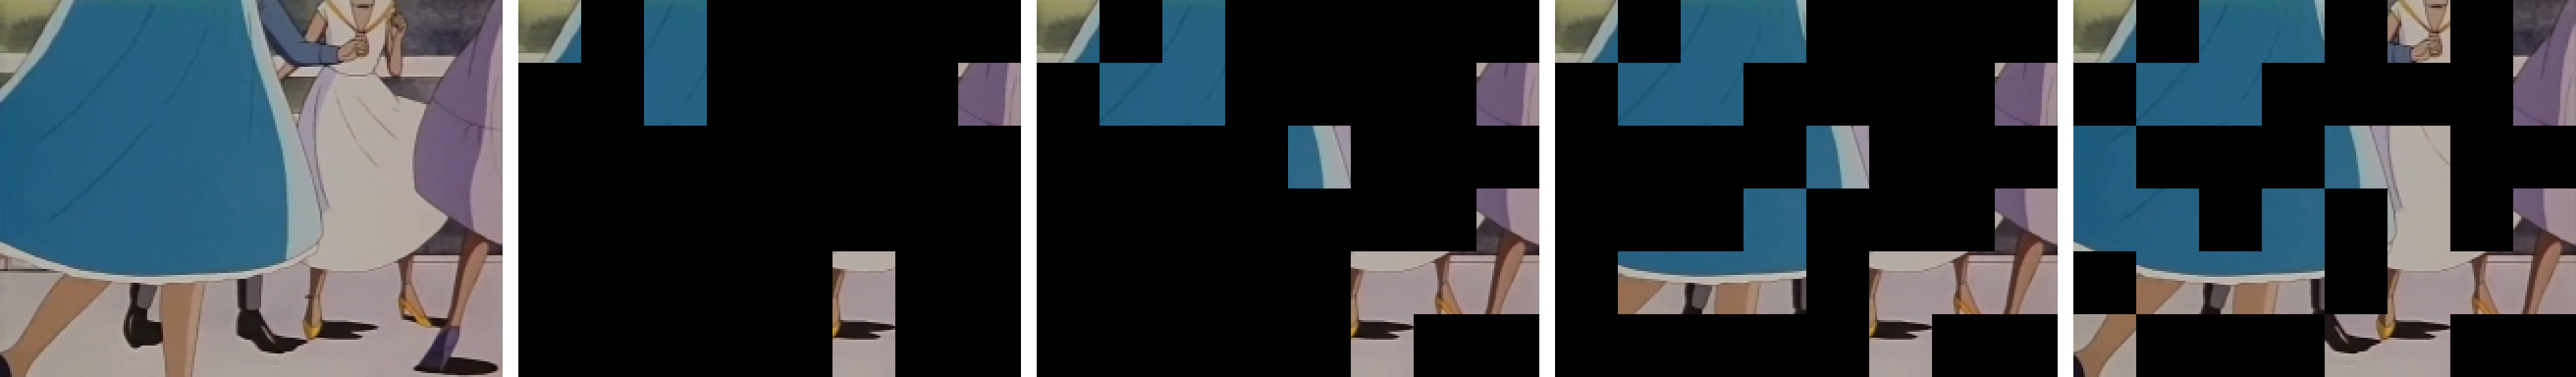

In [12]:
S = json.load(open(f"{A}/qid128_r30/summary.json"))
r0 = S["renders"][0]
display(Markdown(f"**t = {r0['time']:.0f}s — inside the GT evidence window** — kept tokens "
                 + " · ".join(f"r={k}: {v}/{r0['of']}" for k, v in r0["kept"].items())))
display(Image(filename=r0["png"]))

The left panel plainly shows the gold answer — people **dancing**, skirts mid-swirl. At the
production retention of 0.1 the model receives **6 of 48 patches**: a fragment of blue skirt
and one shoe. **The refusal was truthful.** The evidence was destroyed before it reached the
language model.

The obvious response is "raise the retention." We swept it, holding the decoded frames fixed:

In [13]:
lad = Q["ladder"]
print(f"{'retention':>10}{'kept tokens':>14}{'x crop budget':>15}"
      f"{'median kept/frame':>20}{'concentration':>15}")
for r in ["0.1", "0.2", "0.3", "0.5"]:
    v = lad[r]
    print(f"{r:>10}{v['kept']:>14,}{v['x_crop']:>14.1f}x"
          f"{v['median']:>17.0f}/48{v['conc']:>14.2f}x")
print("\nconcentration = share of surviving tokens inside the GT window / uniform expectation")
print("1.00 = the evidence window received exactly its uniform share, i.e. NO preference")
print(f"\nagent rerun at retention 0.3: tool_calls={Q['agent_r03']['tool_calls']}, "
      f"pred={Q['agent_r03']['pred']}, correct={Q['agent_r03']['correct']}")

 retention   kept tokens  x crop budget   median kept/frame  concentration
       0.1         5,714           0.9x                5/48          1.03x
       0.2        11,026           1.8x               10/48          0.99x
       0.3        16,334           2.7x               15/48          1.00x
       0.5        25,902           4.2x               24/48          0.99x

concentration = share of surviving tokens inside the GT window / uniform expectation
1.00 = the evidence window received exactly its uniform share, i.e. NO preference

agent rerun at retention 0.3: tool_calls=[['compress_video', 0, 3296]], pred=None, correct=False


**Concentration is pinned at 1.0 across the entire ladder.** FlashVID is query-blind by
construction — CLS-attention saliency knows nothing about "Coca-Cola" or "dancing". It does
not drop *regions*; it thins **every** frame equally. More budget is simply more uniform
spread.

Three consequences:

1. **Retention is the wrong knob.** At r=0.3 frames become legible, but the tool now costs
   **2.7× `crop_video`'s budget** — destroying its own premise ("many more frames at the same
   token cost"). At that price you could buy 340 clean full-detail frames instead of 1,064
   shredded ones.
2. **The chain cannot complete.** `compress_video` is supposed to answer *"look near here"* so
   `crop_video` can zoom. At 1.0× concentration it carries no such signal, so no window can be
   nominated — and indeed the agent never issued the crop follow-up, at **either** retention.
3. **This explains §1.4.** Uniform sampling beating FlashVID at matched budget is the same fact
   measured at the benchmark level: if the compressor spreads uniformly anyway, its selection
   machinery adds cost and nothing else.

**The bottleneck is *where* the tokens go, not *how many*. That is a query-conditioning
problem, and retention cannot touch it.**

---

# 3. Threats to validity

Stated plainly, because several of these were found by challenging results that looked clean.

### 3.1 The harness costs ~5 pp, concentrated in refusals

`fast_agent` assembles `inputs_embeds` by hand and runs a manual greedy decode instead of
`model.generate`. Parity test on 60 LVBench questions — same frames, same question text, only
the decode path differing:

In [14]:
p = E2["parity"]
print(f"{'path':<34}{'acc':>8}{'no-answer':>12}")
print(f"{'fast_agent custom decode':<34}{pct(p['custom']):>8}{p['custom_none']:>12}")
print(f"{'stock generate, same 64 images':<34}{pct(p['stock_img']):>8}{p['stock_img_none']:>12}")
print(f"{'stock generate, 32 video frames':<34}{pct(p['stock_vid']):>8}{p['stock_vid_none']:>12}")
print(f"\nharness cost: {pp(p['custom']-p['stock_img'])} vs stock on identical frames (n={p['n']})")

path                                   acc   no-answer
fast_agent custom decode             35.0%           7
stock generate, same 64 images       40.0%           1
stock generate, 32 video frames      41.7%           0

harness cost: -5.0pp vs stock on identical frames (n=60)


The gap is **~5 pp and it is almost entirely refusals** — 7 non-answers vs 1, not different
wrong letters.

**What this invalidates:** absolute accuracies in both experiments are depressed, and
`oracle_crop − direct` (+25.7 pp) is **inflated**, because the penalty falls hardest on the arm
that refuses most (direct refuses 12.6%, oracle 1.1%). Best estimate of the true localization
gain vs direct: **≈ +20 pp.**

**What this does NOT invalidate:** the headline `oracle_crop − oracle_ctrl = +23.0 pp` — both
arms share the decode path *and* the refusal regime — and every paired delta in Experiment 1,
where both arms are the same harness.

### 3.2 Other caveats

- **CoT asymmetry (found and corrected).** The oracle's answer turn asked directly for a
  letter while the autonomous arms are told to "think first," suppressing reasoning (69% bare
  answers vs 0%). A controlled rerun with reasoning invited moved the oracle **57.0% → 61.5%**
  (+4.5 pp, p=0.19). So the oracle ceiling is best stated as **57–62%**. The
  oracle-vs-control contrast is unaffected (shared wording).
- **LVBench annotation quality is not clean.** One evidence span runs backwards
  (`[7010, 6480]`); a targeted montage audit found evidence unrelated to the question in ~20%
  of cases checked. ~20 of 183 questions are recommended for exclusion. This adds noise; it
  does not have a direction that would manufacture a +23 pp effect.
- **n = 30 on the single-shot and official-FlashVID ladders.** A single arm's 95% CI is ~±18 pp.
  Individual −3 pp points there are noise; the load-bearing observation is that **nothing shows
  a gain** and the sign is consistently negative.
- **§2.5 is one case.** It demonstrates a mechanism (uniform token spreading) that is confirmed
  in aggregate by §1.4, but qid 128 itself fails in **all five arms**, including the oracle —
  handed the GT window at full detail the model still misses it, disagreeing about the
  temporal scope of "before." It is a clean illustration of what compression destroys; it is
  **not** a case where fixing compression would flip the answer.
- **Not tested:** query-aware compression. The entire compression conclusion here is about
  *uniform, query-blind* compression.

---

# 4. What the two experiments jointly establish

**1. Zero-shot tool use is worth nothing, and now we know why.** Experiment 1 measured the null
(−1.0 pp, p=0.50, 16% symmetric churn). Experiment 2 supplied the cause: the agent inspects a
median **1.6%** of the video and never reaches the evidence on **79%** of questions. The tools
were never given anything to work with.

**2. The prize is large and it is entirely about placement.** +23.0 pp (p=3.1e-8) for putting
the *same number of pixels* in the right place versus the wrong place. The control arm sits on
top of `direct`, which kills the "more tokens help" explanation outright.

**3. The failure is reach, not perception.** Aim correlation r=0.95 on questions the agent
covers; near-oracle accuracy once it arrives; and questions that state their own timestamp get
**4.7× the coverage and nearly double the accuracy** from the identical model and tool. It
knows what it's looking for and cannot cover enough ground.

**4. Uniform compression cannot fix reach, and more retention cannot fix uniform compression.**
Measured concentration is **1.0 at every retention from 0.1 to 0.5** — the compressor gives the
evidence window exactly its uniform share, always. That is why a dumb uniform subsample beats
it at matched budget, why the compress→crop chain never completes, and why raising retention
changes cost without changing behaviour.

**5. The ceiling is real.** 43% of questions fail with perfect evidence, ~88% of those from base
perception. A perfect WHERE-policy is worth roughly **57% → 76%**, not 57% → 100%.

### The one-sentence version

> The bottleneck is **allocation, not perception**: the agent knows what it is looking for and
> answers well once it arrives, but cannot search an hour of video with five crops — and the
> coverage tool that should solve this spreads its budget uniformly, so it destroys the
> evidence it was meant to locate.

### What follows

| priority | test | what it decides |
|---|---|---|
| **1** | **Query-aware compression** (`FA_COMPRESSOR=semvid`), matched budget, only the selection rule changing. Metric: **concentration**. | FlashVID is 1.0 at every retention. If a query-conditioned selector lifts it materially, `compress→crop` becomes viable and coverage-as-an-action survives. If not, whole-video compression should be dropped as a localization primitive. |
| **2** | **Search budget/shape ablation** — 8 calls, first two forced wide (≥300 s) reconnaissance, nothing else changed. | If coverage rises from 0.18 past ~0.35, the deficit is search *reach* and RL on the WHERE-policy will work. If it stays flat, the skim doesn't carry the signal and the answer is architectural. |
| **3** | **Fix the harness decode** (~5 pp, refusal-dominated) or move to stock `generate`. | Every absolute number in this report is depressed until this is done. |

**A warning for the training phase.** In §2.5 the model made the *correct* opening move —
coarse-to-fine, unprompted — and was penalised for it, because the tool returned unusable
output. Under an outcome-only reward, that trajectory trains the model **away** from the right
strategy. Reward shaping must credit the opening move, or RL will select against coarse-to-fine
before the tool is ever good enough to reward it.